# Spotify US Daily Top 200: Markov chain of chart positions

Data: `data/spotify_us_daily_top200_2017_2026.csv.gz`, Spotify's US Daily Top 200 from 2017-01-01 to 2026-09-17 (709,397 rows).
Built by `scripts/build_us_top200.py`. See the README for the schema.

In [1]:
import pandas as pd

file_path = "../data/spotify_us_daily_top200_2017_2026.csv.gz"
df = pd.read_csv(file_path, parse_dates=["chart_date"])
df.head()

,chart_date,rank,prev_rank,peak_rank,streak,days_on_chart,streams,track_name,artists,track_uri,release_date,labels
0,2017-01-01,1,NaN,1,NaN,1,1371493,Bad and Boujee (feat. Lil Uzi Vert),Migos|Lil Uzi Vert,spotify:track:4Km5HrUvYTaSUfiSGPJeQR,2017-01-27,Quality Control Music
1,2017-01-01,2,NaN,2,NaN,1,1180074,Fake Love,Drake,spotify:track:343YBumqHu19cGoGARUTsd,2017-03-18,Cash Money Records/Young Money Ent./Universal ...
2,2017-01-01,3,NaN,3,NaN,1,1064351,Starboy,The Weeknd|Daft Punk,spotify:track:5aAx2yezTd8zXrkmtKl66Z,2016-11-25,The Weeknd/Lyric
3,2017-01-01,4,NaN,4,NaN,1,1010492,Closer,The Chainsmokers|Halsey,spotify:track:7BKLCZ1jbUBVqRi2FVlTVw,2016-07-29,Disruptor Records/Columbia
4,2017-01-01,5,NaN,5,NaN,1,874289,Black Beatles,Rae Sremmurd|Gucci Mane,spotify:track:6fujklziTHa8uoM5OQSfIo,2016-08-12,Mike WiLL Made-It


In [2]:
# track_uri is the song ID: it is unique per recording, unlike song name + artist
df = df.rename(columns={"chart_date": "date", "track_name": "song", "artists": "artist", "track_uri": "song_id"})
df = df.sort_values(["song_id", "date"])
df = df[["date", "rank", "song", "artist", "song_id"]]
df.head()

,date,rank,song,artist,song_id
16452,2017-03-24,53,Still Got Time (feat. PARTYNEXTDOOR),ZAYN|PARTYNEXTDOOR,spotify:track:000xQL6tZNLJzIrtIgxqSl
16689,2017-03-25,90,Still Got Time (feat. PARTYNEXTDOOR),ZAYN|PARTYNEXTDOOR,spotify:track:000xQL6tZNLJzIrtIgxqSl
16886,2017-03-26,87,Still Got Time (feat. PARTYNEXTDOOR),ZAYN|PARTYNEXTDOOR,spotify:track:000xQL6tZNLJzIrtIgxqSl
17061,2017-03-27,62,Still Got Time (feat. PARTYNEXTDOOR),ZAYN|PARTYNEXTDOOR,spotify:track:000xQL6tZNLJzIrtIgxqSl
17254,2017-03-28,55,Still Got Time (feat. PARTYNEXTDOOR),ZAYN|PARTYNEXTDOOR,spotify:track:000xQL6tZNLJzIrtIgxqSl


In [3]:
'''
State definitions

1-10, 11-20, 21-30, 31-40, 41-50 - ten-rank bins at the top of the chart
51-100, 101-150, 151-200 - wider bins for the rest of the Top 200
off-chart - not on the chart that day (has been on the chart before)
'''

BINS = [(1, 10), (11, 20), (21, 30), (31, 40), (41, 50), (51, 100), (101, 150), (151, 200)]
STATES = [f"{lo}-{hi}" for lo, hi in BINS] + ["off-chart"]

def get_state(rank):
    for lo, hi in BINS:
        if lo <= rank <= hi:
            return f"{lo}-{hi}"
    return None

df["state"] = df["rank"].apply(get_state)
df = df[["date", "rank", "song", "artist", "song_id", "state"]].copy()
df["state"].value_counts().reindex(STATES)

state
1-10          35470.0
11-20         35470.0
21-30         35470.0
31-40         35469.0
41-50         35470.0
51-100       177349.0
101-150      177350.0
151-200      177349.0
off-chart         NaN
Name: count, dtype: float64

Each song is tracked from its first chart appearance to the end of the dataset.
A day on the chart keeps its actual state; any other day is off-chart.

A full day-by-song panel would be about 17M rows here, so transitions are counted directly:
- **From a chart state:** tomorrow's state if the song charts tomorrow, otherwise off-chart.
- **From off-chart:** re-entries go to the state they re-enter at. Every other off-chart day stays off-chart.

The counts are the same as the panel method gives.

In [4]:
sample_end = df["date"].max()

# next day's state for each on-chart row
nxt = df[["song_id", "date", "state"]].copy()
nxt["date"] = nxt["date"] - pd.Timedelta(days=1)
on = df.merge(nxt.rename(columns={"state": "next_state"}), on=["song_id", "date"], how="left")
on = on[on["date"] < sample_end]
on["next_state"] = on["next_state"].fillna("off-chart")

# re-entries: on the chart today, off yesterday, and not the song's first day
first_date = df.groupby("song_id")["date"].transform("min")
prev_day = df[["song_id", "date"]].assign(date=lambda x: x["date"] + pd.Timedelta(days=1), was_on=True)
chk = df.assign(first_date=first_date).merge(prev_day, on=["song_id", "date"], how="left")
reentries = chk[(chk["was_on"].isna()) & (chk["date"] > chk["first_date"])]

# off-chart days from the first appearance to the day before sample_end
span = df.groupby("song_id")["date"].agg(first="min", n_on="size")
last_on = df[df["date"] == sample_end]["song_id"]
off_days = ((sample_end - span["first"]).dt.days + 1 - span["n_on"]).sum()   # off days incl. sample_end
off_days_before_end = off_days - (span.index.size - last_on.nunique())     # drop sample_end off days

transitions_df = on[["date", "song", "state", "next_state"]]
transitions_df.head(20)

,date,song,state,next_state
0,2017-03-24,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
1,2017-03-25,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
2,2017-03-26,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
3,2017-03-27,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
4,2017-03-28,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
5,2017-03-29,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
6,2017-03-30,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
7,2017-03-31,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
8,2017-04-01,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100
9,2017-04-02,Still Got Time (feat. PARTYNEXTDOOR),51-100,51-100


Generate the transition probability matrix

In [5]:
transition_counts = pd.crosstab(on["state"], on["next_state"])
transition_counts = transition_counts.reindex(index=STATES, columns=STATES, fill_value=0)

reentry_counts = reentries["state"].value_counts()
transition_counts.loc["off-chart"] = reentry_counts.reindex(STATES, fill_value=0)
transition_counts.loc["off-chart", "off-chart"] = off_days_before_end - reentry_counts.sum()

transition_counts

next_state,1-10,11-20,21-30,31-40,41-50,51-100,101-150,151-200,off-chart
state,,,,,,,,,
1-10,31397,3195,420,105,33,43,16,1,250
11-20,2315,27111,4629,800,233,144,25,23,180
21-30,92,3571,24202,5617,1094,634,34,18,198
31-40,36,234,4638,22018,6017,2197,109,16,194
41-50,24,58,399,5336,21204,7977,204,52,206
51-100,71,83,185,678,5963,147020,20225,1248,1826
101-150,28,47,67,60,85,14690,132196,25547,4580
151-200,6,19,28,51,73,696,19752,120244,36430
off-chart,37,46,39,54,67,673,2037,26063,28820512


In [6]:
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
state_order = STATES

transition_matrix.round(3)

next_state,1-10,11-20,21-30,31-40,41-50,51-100,101-150,151-200,off-chart
state,,,,,,,,,
1-10,0.885,0.090,0.012,0.003,0.001,0.001,0.000,0.000,0.007
11-20,0.065,0.765,0.131,0.023,0.007,0.004,0.001,0.001,0.005
21-30,0.003,0.101,0.683,0.158,0.031,0.018,0.001,0.001,0.006
31-40,0.001,0.007,0.131,0.621,0.170,0.062,0.003,0.000,0.005
41-50,0.001,0.002,0.011,0.150,0.598,0.225,0.006,0.001,0.006
51-100,0.000,0.000,0.001,0.004,0.034,0.829,0.114,0.007,0.010
101-150,0.000,0.000,0.000,0.000,0.000,0.083,0.746,0.144,0.026
151-200,0.000,0.000,0.000,0.000,0.000,0.004,0.111,0.678,0.205
off-chart,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.999


# Data Vizualization

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap="Blues")
plt.title("Daily Markov Transition Matrix for Spotify US Top 200 (2017-2026)")
plt.xlabel("Next Day State")
plt.ylabel("Current State")
plt.show()

<Figure size 1000x800 with 2 Axes>

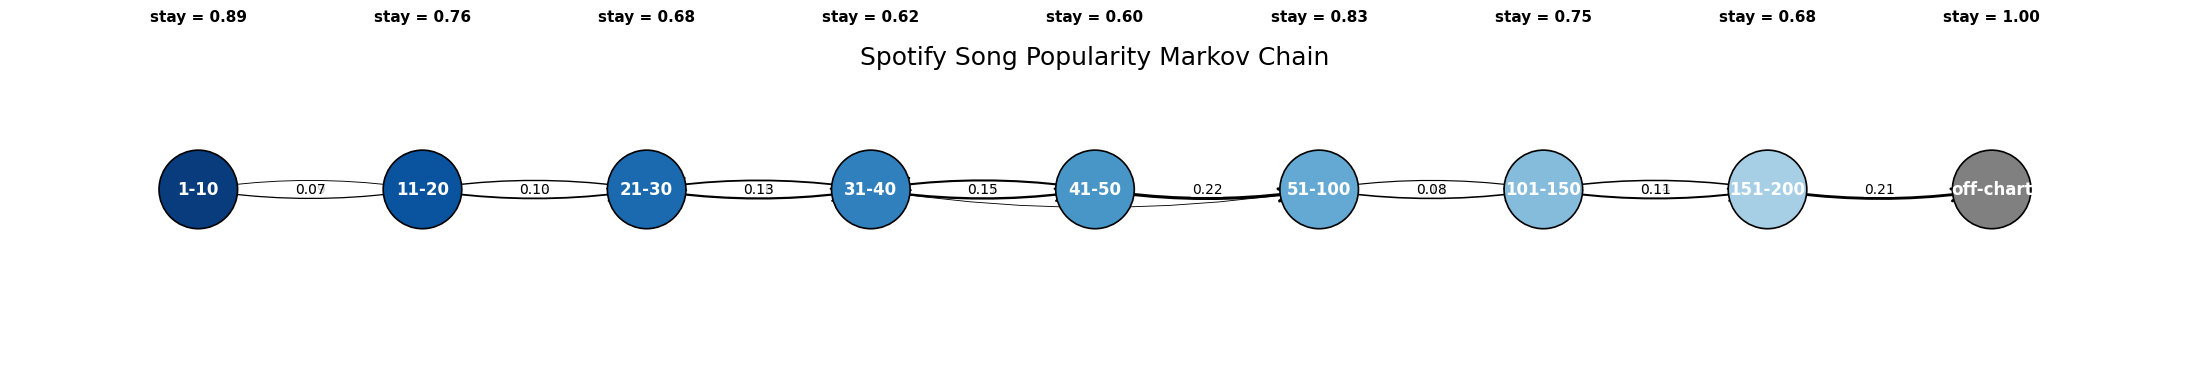

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# ordered states
states = STATES

# build graph with ONLY non-self transitions above threshold
G = nx.DiGraph()
for state in states:
    G.add_node(state)

threshold = 0.05  # only show non-self transitions >= 5%

for from_state in states:
    for to_state in states:
        prob = transition_matrix.loc[from_state, to_state]
        if from_state != to_state and prob >= threshold:
            G.add_edge(from_state, to_state, weight=prob)

# cleaner pyramid layout
pos = {state: (i, 0) for i, state in enumerate(states)}
# node colors
blues = plt.cm.Blues_r([0.05 + 0.6 * i / (len(states) - 2) for i in range(len(states) - 1)])
node_color_map = dict(zip(states[:-1], blues))
node_color_map["off-chart"] = "gray"
node_colors = [node_color_map[state] for state in states]

# edge widths scaled by probability
edge_widths = [10 * G[u][v]["weight"] for u, v in G.edges()]

# edge labels
edge_labels = {
    (u, v): f"{G[u][v]['weight']:.2f}"
    for u, v in G.edges()
}

plt.figure(figsize=(22, 4))

# draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3200,
    node_color=node_colors,
    edgecolors="black",
    linewidths=1.2
)

# draw node labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=12,
    font_color="white",
    font_weight="bold"
)

# draw edges
nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=22,
    width=edge_widths,
    edge_color="black",
    min_source_margin=18,
    min_target_margin=18,
    connectionstyle="arc3,rad=0.08"
)

# draw edge labels
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=10,
    rotate=False,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=0.2)
)

# add self-transition probabilities as text above nodes
for state in states:
    x, y = pos[state]
    stay_prob = transition_matrix.loc[state, state]
    plt.text(
        x, y + 0.45,
        f"stay = {stay_prob:.2f}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=0.2)
    )

plt.title("Spotify Song Popularity Markov Chain", fontsize=18, pad=20)
plt.axis("off")
plt.tight_layout()
plt.show()


DISCRETE-TIME MARKOV CHAIN
 SIZE:           9
 RANK:           9
 CLASSES:        1
  > RECURRENT:   1
  > TRANSIENT:   0
 ERGODIC:        YES
  > APERIODIC:   YES
  > IRREDUCIBLE: YES
 ABSORBING:      NO
 MONOTONE:       NO
 REGULAR:        YES
 REVERSIBLE:     NO
 SYMMETRIC:      NO



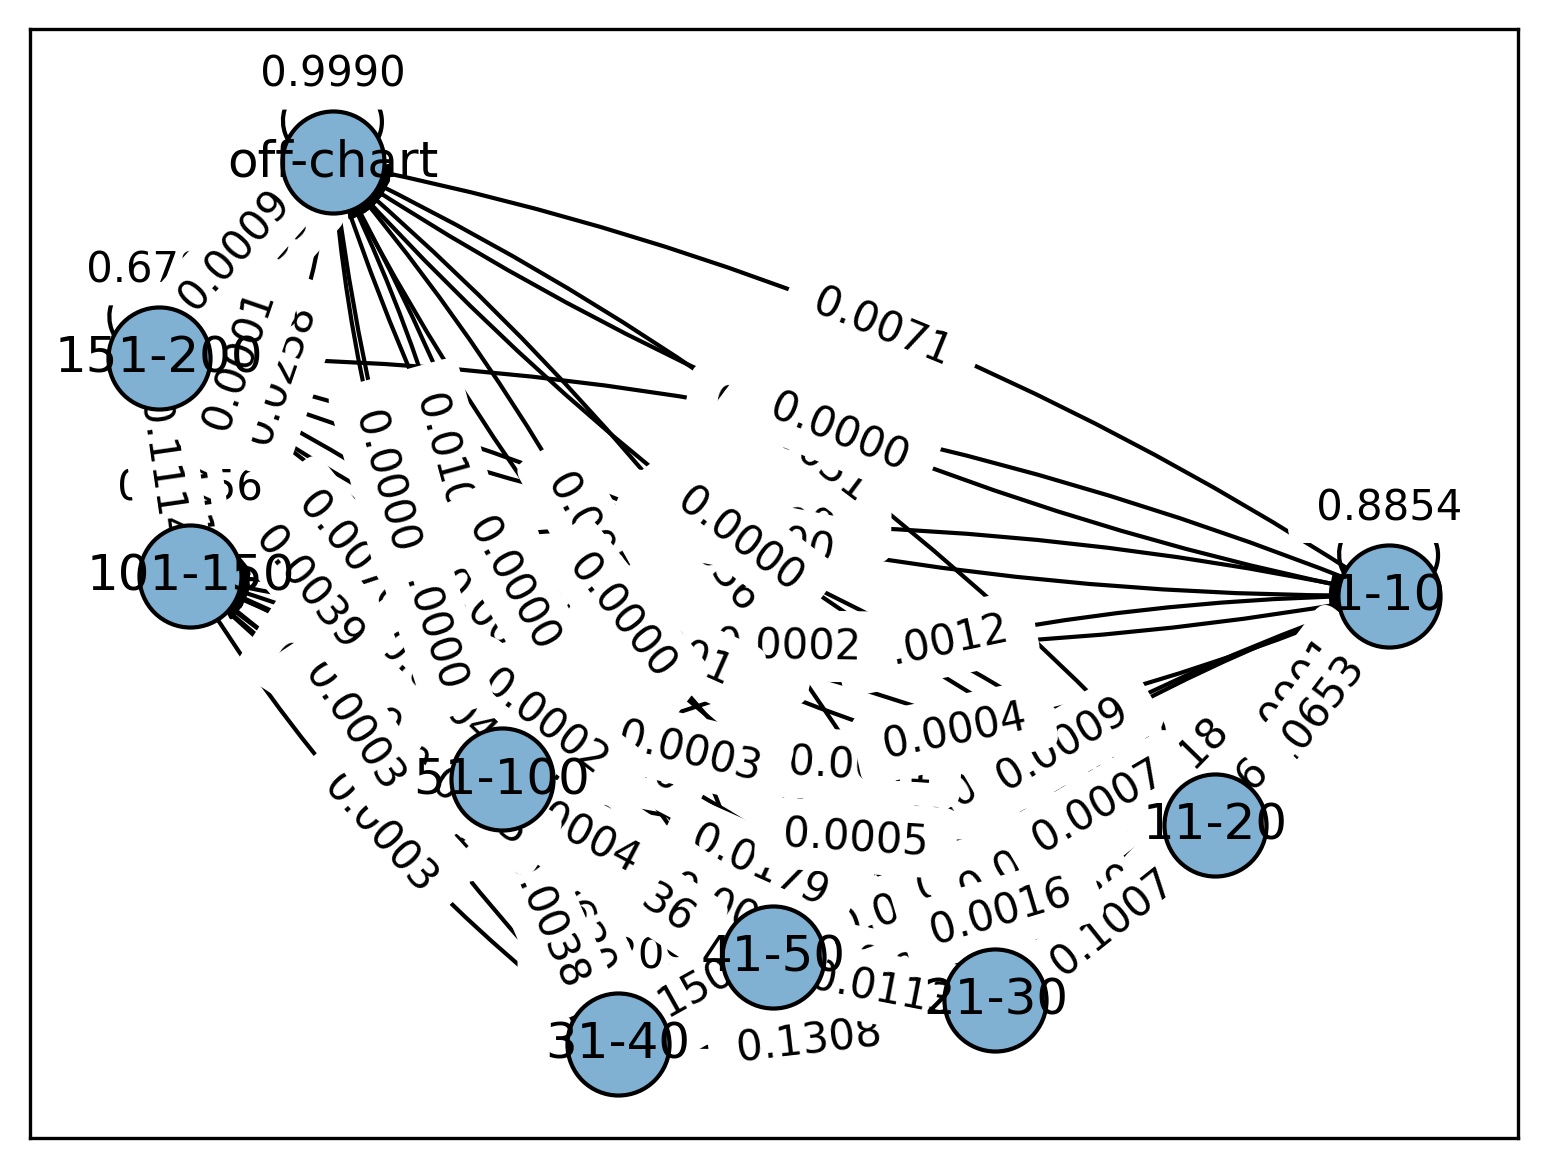

In [9]:
from pydtmc import MarkovChain, plot_graph

state_order = STATES

P = transition_matrix.reindex(index=state_order, columns=state_order).to_numpy()
mc = MarkovChain(P, state_order)

print(mc)
plot_graph(mc, dpi=300)

In [10]:
'''
NOTES- 

There should be  a state for not entered the chart yet , whether released on unreleased. Gives a better idea 
Creating a Markov Chain directed graph that has a more intuitive visualization. 
Looking at weekly rather than daily 
Observing edge cases where the ones that are at the beginning of the time series are immediately projected to their ranking which can skew the data 

'''

'\nNOTES- \n\nThere should be  a state for not entered the chart yet , whether released on unreleased. Gives a better idea \nCreating a Markov Chain directed graph that has a more intuitive visualization. \nLooking at weekly rather than daily \nObserving edge cases where the ones that are at the beginning of the time series are immediately projected to their ranking which can skew the data \n\n'